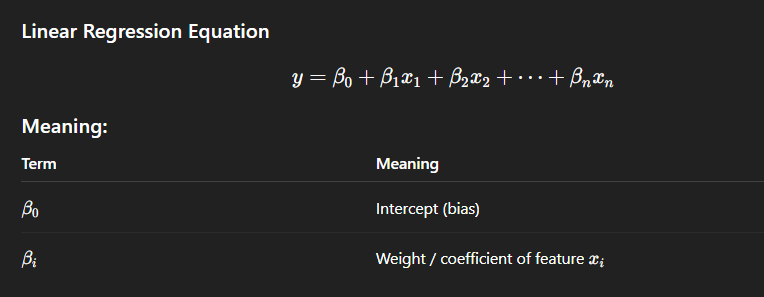

Regularization prevents overfitting by penalizing large coefficients.

L1 Regularization / Lasso : performs feature selection.

L2 Regularization / Ridge : stabilizes coefficients.

β represents feature importance.

Learning Rate = “How fast to learn” / alpha controls the step size of gradient descent.
Lambda = “How simple to stay” / Lambda controls regularization strength. 

# L1 Regularization (Lasso Regression) 
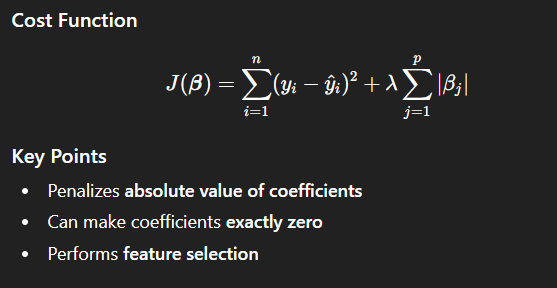

# L2 Regularization (Ridge Regression)
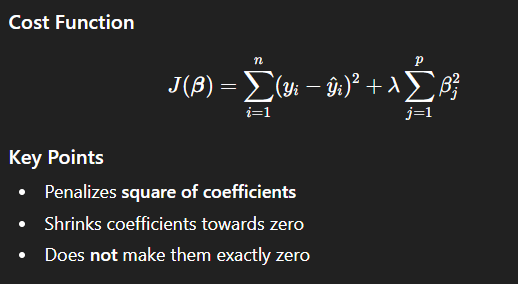

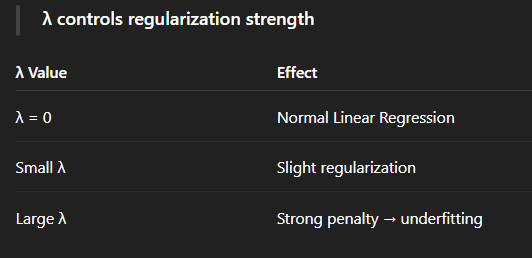


Lambda balances bias and variance by controlling model complexity.

### Bias:
How wrong your model is on average.
High bias → model is too simple
Model does not learn the pattern properly
Underfitting : When a model is too simple to capture the underlying pattern in the data.

### Variance : 
How much your model changes when data changes slightly.
High variance → model is too complex
Model learns noise also
Overfitting : When a model learns the training data (including noise) too well and performs poorly on new data.


- Bias = too simple model
- Variance = too complex model
- λ controls complexity
- Small λ → overfitting
- Large λ → underfitting
- Perfect λ → best balance

A good model has low bais and low variance = Bias–Variance Tradeoff (cannot minimize both at the same time) so we find λ where test error is minimum

In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso, Ridge 
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
california = fetch_california_housing()
data = pd.DataFrame(california.data, columns=california.feature_names)
data['MedHouseVal'] = california.target

In [25]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [26]:
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### APPLY LINEAR REGRESSION

In [30]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

In [31]:
print(f"MSE Linear Reg : {mse_linear}")

MSE Linear Reg : 0.5558915986952442


In [32]:
linear_reg.coef_

array([ 0.85438303,  0.12254624, -0.29441013,  0.33925949, -0.00230772,
       -0.0408291 , -0.89692888, -0.86984178])

In [33]:
print(f"R2 Linear Reg : {r2_linear}")

R2 Linear Reg : 0.575787706032451


### APPLY LASSO REGRESSION

In [35]:
lasso_reg = Lasso(alpha=0.1)  # here alpha is λ
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [36]:
print(f"MSE Lasso Reg : {mse_lasso}")

MSE Lasso Reg : 0.6796290284328825


In [37]:
print(f"R2 Lasso Reg : {r2_lasso}")

R2 Lasso Reg : 0.48136113250290735


In [38]:
lasso_reg.coef_

array([ 0.71059779,  0.1064527 , -0.        ,  0.        , -0.        ,
       -0.        , -0.01146856, -0.        ])

### APPLY RIDGE

In [40]:
ridge_reg = Ridge(alpha=0.1) # also use 0.1
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [41]:
print(f"MSE Ridge Reg : {mse_ridge}")

MSE Ridge Reg : 0.5558879138674184


In [42]:
print(f"R2 Ridge Reg : {r2_ridge}")

R2 Ridge Reg : 0.5757905180002312


In [43]:
ridge_reg.coef_

array([ 0.85437741,  0.12255402, -0.29439016,  0.33923433, -0.00230517,
       -0.0408295 , -0.89685268, -0.8697646 ])

In [44]:
ridge_reg.intercept_

2.0719469373788777